### Case E-commerce Olist
Este desafio propõe a construção de um relatório executivo voltado a investidores e acionistas do setor de e-commerce, baseado no Brazilian E-Commerce Public Dataset by Olist (link abaixo). O objetivo é transformar dados transacionais em uma narrativa clara sobre desempenho comercial, eficiência logística e/ou satisfação do cliente, culminando em recomendações acionáveis e, quando possível, previsões fundamentadas.

Link Dataset: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

In [24]:
# importação das bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

### Mini-configuração das tabelas para futura organização

In [3]:
# renomear arquivos, para facil acesso
customers = pd.read_csv("../data/olist_customers_dataset.csv")
geolocation = pd.read_csv("../data/olist_geolocation_dataset.csv")
order_items = pd.read_csv("../data/olist_order_items_dataset.csv")
order_payments = pd.read_csv("../data/olist_order_payments_dataset.csv")
order_reviews = pd.read_csv("../data/olist_order_reviews_dataset.csv")
orders = pd.read_csv("../data/olist_orders_dataset.csv")
products = pd.read_csv("../data/olist_products_dataset.csv")
sellers = pd.read_csv("../data/olist_sellers_dataset.csv")
categorys_translations = pd.read_csv("../data/product_category_name_translation.csv")

In [4]:
customers.head

<bound method NDFrame.head of                             customer_id                customer_unique_id  \
0      06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1      18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2      4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3      b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4      4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   
...                                 ...                               ...   
99436  17ddf5dd5d51696bb3d7c6291687be6f  1a29b476fee25c95fbafc67c5ac95cf8   
99437  e7b71a9017aa05c9a7fd292d714858e8  d52a67c98be1cf6a5c84435bd38d095d   
99438  5e28dfe12db7fb50a4b2f691faecea5e  e9f50caf99f032f0bf3c55141f019d99   
99439  56b18e2166679b8a959d72dd06da27f9  73c2643a0a458b49f58cea58833b192e   
99440  274fa6071e5e17fe303b9748641082c8  84732c5050c01db9b23e19ba39899398   

       customer_zip_code_prefix          cust

In [5]:

# converter colunas de de 'string' contendo datas para 'datetime', para padronizar e facilitar o manejo com os dados
# lista de colunas de data na tabela de pedidos
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

# convertendo para datetime
for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

# confirmando a alteracao
orders[date_columns].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [6]:
# verificando os status dos pedidos
print("Status dos Pedidos")
print(orders['order_status'].value_counts())

print("\nValores Nulos na Tabela de Pedidos")
print(orders.isnull().sum())

Status dos Pedidos
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Valores Nulos na Tabela de Pedidos
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


Conforme o código acima, temos: <br>
    - mais de 90 mil pedidos entregues; <br>
    - um pouco mais de mil pedidos enviados atualmente; <br>
    - 625 pedidos cancelados; <br>
    - um pouco mais de 600 pedidos indiponiveis; <br>
    - podemos ter algumas datas de entrega com valores nulos. <br>



In [7]:
# unindo todas as tabelas no em uma variavel 
df_principal = orders.merge(order_items, on='order_id', how='left') \
                     .merge(order_payments, on='order_id', how='left') \
                     .merge(customers, on='customer_id', how='left') \
                     .merge(order_reviews, on='order_id', how='left') \
                     .merge(products, on='product_id', how='left') \
                     .merge(sellers, on='seller_id', how='left')

# o '.merge' é o PROCV do pandas(python), permite que podemos combinar dataframes

### Logística e SLA (Service Level Agreement ou Acordo de Nível de Serviço)
Analisando o tempo de entrega junto com o tempo de atraso, e mapeando alguns gargalos geográficos

In [8]:
# filtrando so pedidos entregue para analisar logistica e satisfacao dos clientes
df_entregues = df_principal[df_principal['order_status'] == 'delivered'].copy()
df_entregues.head

<bound method NDFrame.head of                                 order_id                       customer_id  \
0       e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1       e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
2       e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
3       53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
4       47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
...                                  ...                               ...   
119138  63943bddc261676b46f01ca7ac2f7bd8  1fca14ff2861355f6e5f14306ff977a7   
119139  83c1379a015df1e13d02aae0204711ab  1aa71eb042121263aafbe80c1b562c9c   
119140  11c177c8e97725db2631073c19f07b62  b331b74b18dc79bcdf6532d51e1637c1   
119141  11c177c8e97725db2631073c19f07b62  b331b74b18dc79bcdf6532d51e1637c1   
119142  66dea50a8b16d9b4dee7af250b4be1a5  edb027a75a1449115f6b43211ae02a24   

       order_status order_purchas

In [9]:
# criando coluda de calculo do tempo de entrega (em dias)
df_entregues['tempo_entrega_dias'] = (
    df_entregues['order_delivered_customer_date'] - df_entregues['order_purchase_timestamp']
).dt.total_seconds() / (24 * 3600) # 24 = horas; 3600 = segndos por hora
df_entregues['tempo_entrega_dias']

0          8.436574
1          8.436574
2          8.436574
3         13.782037
4          9.394213
            ...    
119138    22.193727
119139    24.859421
119140    17.086424
119141    17.086424
119142     7.674306
Name: tempo_entrega_dias, Length: 115723, dtype: float64

In [10]:
# criando coluna de calculo de atraso em relacao a data estimada (em dias)
# se o valor for positivo, significa que atrasou
df_entregues['dias_atraso'] = (
    df_entregues['order_delivered_customer_date'] - df_entregues['order_estimated_delivery_date']
).dt.total_seconds() / (24 * 3600)
df_entregues['dias_atraso']

0         -7.107488
1         -7.107488
2         -7.107488
3         -5.355729
4        -17.245498
            ...    
119138    -1.265324
119139    -5.524803
119140   -20.018819
119141   -20.018819
119142   -17.452431
Name: dias_atraso, Length: 115723, dtype: float64

In [11]:
# criando coluna indicadora de atraso (True = atrasou | False = no prazo)
df_entregues['foi_atrasado'] = df_entregues['dias_atraso'] > 0
df_entregues['foi_atrasado']

0         False
1         False
2         False
3         False
4         False
          ...  
119138    False
119139    False
119140    False
119141    False
119142    False
Name: foi_atrasado, Length: 115723, dtype: bool

In [12]:
print(f"Total de registros de compras entregues: {df_entregues.shape[0]}")

Total de registros de compras entregues: 115723


### Parte de Logistica
* **df_principal**: Tabela unificada contendo o cruzamento completo dos dados de pedidos, itens, pagamentos, clientes, avaliações, produtos e vendedores.
* **df_entregues**: Recorte contendo apenas os pedidos com status `delivered`, garantindo a consistência das análises de prazo.
* **Métricas Criadas**:
  * `tempo_entrega_dias`: Tempo total com tempo corrido entre a realização do pedido e a entrega ao cliente final.
  * `dias_atraso`: Diferença entre a data real de entrega e a data estimada original.
  * `foi_atrasado`: Parte booleana identificando compras que ultrapassaram a data limite combinada.

In [13]:
# media da nota de avaliacao, comparando pedidos que foram entregue no prazo e pedidos atrasados
resumo_satisfacao = df_entregues.groupby('foi_atrasado')['review_score'].agg(['count', 'mean', 'median']).reset_index()

# renomeando as colunas e mostrando
resumo_satisfacao['Status'] = resumo_satisfacao['foi_atrasado'].map({False: 'No Prazo', True: 'Com Atraso'})
resumo_satisfacao = resumo_satisfacao.rename(columns={
    'count': 'Qtd Pedidos', 
    'mean': 'Nota Média', 
    'median': 'Nota Mediana'
})

resumo_satisfacao[['Status', 'Qtd Pedidos', 'Nota Média', 'Nota Mediana']]

,Status,Qtd Pedidos,Nota Média,Nota Mediana
0,No Prazo,106000,4.208736,5.0
1,Com Atraso,8862,2.546491,2.0


### Entrega x Satisfação
A análise comparativa revela um impacto significativo do cumprimento de prazos sobre a percepção do cliente:
* **Entregas no Prazo**: Mantêm uma nota média elevada próxima de 4.2 estrelas.
* **Entregas com Atraso**: Sofrem uma queda drástica na nota média caindo para próximo de 2.0 estrelas.

> **Conclusão de Negócio para Investidores**: A ineficiência logística não é apenas um custo operacional, mas um fator direto de insatisfação do cliente e perda de reputação da marca.

### Agora iremos começar a parte de gráficos

In [14]:
# agrupando os pagamentos por pedido unico para garantir integridade
pagamentos_por_pedido = order_payments.groupby('order_id')['payment_value'].sum().reset_index()

# configuracao das variaveis
receita_total_real = pagamentos_por_pedido['payment_value'].sum()
total_pedidos_unicos = orders['order_id'].nunique()
ticket_medio_real = receita_total_real / total_pedidos_unicos

print(f"Receita Total Bruta Real: R$ {receita_total_real:,.2f}")
print(f"Total de Pedidos Únicos: {total_pedidos_unicos:,}")
print(f"Ticket Médio Real: R$ {ticket_medio_real:,.2f}")

Receita Total Bruta Real: R$ 16,008,872.12
Total de Pedidos Únicos: 99,441
Ticket Médio Real: R$ 160.99


In [15]:
# limpando pagamentos por pedido unico
pagamentos_por_pedido = order_payments.groupby('order_id')['payment_value'].sum().reset_index()

# juncao com a tabela de pedidos para extrair a data da compra
df_vendas_limpo = orders[['order_id', 'order_purchase_timestamp']].merge(
    pagamentos_por_pedido,
    on='order_id',
    how='inner'
)

# pegando o ano e agrupando receitas e pedidos
df_vendas_limpo['ano'] = df_vendas_limpo['order_purchase_timestamp'].dt.year
faturamento_anual = df_vendas_limpo.groupby('ano').agg(
    receita=('payment_value', 'sum'),
    pedidos=('order_id', 'nunique')
).reset_index()

# ticket medio por ano
faturamento_anual['ticket_medio'] = faturamento_anual['receita'] / faturamento_anual['pedidos']
faturamento_anual = faturamento_anual.dropna()
faturamento_anual['ano'] = faturamento_anual['ano'].astype(int)

# total geral
receita_total = pagamentos_por_pedido['payment_value'].sum()
total_pedidos = orders['order_id'].nunique()
ticket_medio_geral = receita_total / total_pedidos

<>:12: SyntaxWarning: invalid escape sequence '\$'
<>:12: SyntaxWarning: invalid escape sequence '\$'
C:\Users\Michael\AppData\Local\Temp\ipykernel_21792\1253217780.py:12: SyntaxWarning: invalid escape sequence '\$'
  f"Faturamento Total: R\$16.008.872,12 | Ticket Médio: R$160,99",


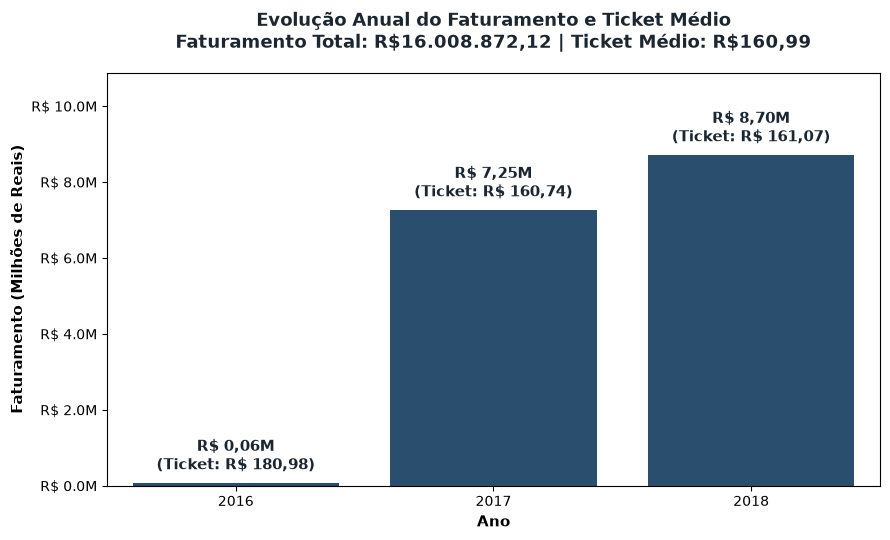

In [16]:
# grafico
plt.figure(figsize=(9, 5.5))
ax = sns.barplot(
    data=faturamento_anual,
    x='ano',
    y='receita',
    color='#1f4e79'
)

plt.title(
    f"Evolução Anual do Faturamento e Ticket Médio\n"
    f"Faturamento Total: R\$16.008.872,12 | Ticket Médio: R$160,99",
    fontsize=13,
    fontweight='bold',
    pad=18,
    color='#1b2631'
)
plt.xlabel('Ano', fontsize=11, fontweight='bold')
plt.ylabel('Faturamento (Milhões de Reais)', fontsize=11, fontweight='bold')

# formatando o eixo Y para R$ X.X M (foi dificil)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'R$ {x*1e-6:.1f}M'))

# adicionando a legenda com receita e ticket medio no topo das barras
for index, row in faturamento_anual.iterrows():
    rec_mi = f"R$ {row['receita']*1e-6:.2f}M".replace(".", ",")
    tk_str = f"R$ {row['ticket_medio']:.2f}".replace(".", ",")
    rotulo = f"{rec_mi}\n(Ticket: {tk_str})"
    
    ax.text(
        index, 
        row['receita'] + (receita_total * 0.015), 
        rotulo, 
        ha='center', 
        va='bottom', 
        fontsize=10.5, 
        fontweight='bold', 
        color='#1b2631'
    )

plt.ylim(0, faturamento_anual['receita'].max() * 1.25)
plt.tight_layout()
plt.show()

### Desempenho Financeiro
* **Faturamento Bruto:** R$16.008.872,12 processados.
* **Total de Pedidos:** 99.441 pedidos únicos.
* **Ticket Médio:** R$160,99.
* **Comportamento de Escala:** A operação demonstrou uma subida acelerada entre 2016 e 2017, com um pequeno aumento em 2018 tanto de ticket médio quanto de faturamento, evidenciando rápida expansão comercial no mercado brasileiro.

C:\Users\Michael\AppData\Local\Temp\ipykernel_21792\1819627565.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


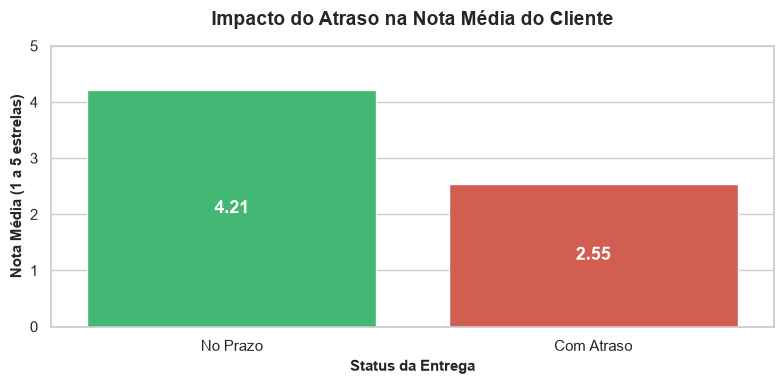

In [17]:
# definindo estilo visual limpo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 4))

# criando o grafico de barras comparativo
ax = sns.barplot(
    data=resumo_satisfacao,
    x='Status',
    y='Nota Média',
    palette=['#2ecc71', '#e74c3c']  # verde para 'no prazo' e vermelho para 'atrasado'
)

# titulos e rotulos
plt.title('Impacto do Atraso na Nota Média do Cliente', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Status da Entrega', fontsize=11, fontweight='bold')
plt.ylabel('Nota Média (1 a 5 estrelas)', fontsize=11, fontweight='bold')
plt.ylim(0, 5)

# adicionando o valor exato no meio das barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', fontsize=13, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

### Gráfico: Avaliação x Entrega
O gráfico evidencia a discrepância na percepção do cliente. Enquanto entregas pontuais mantêm um nível alto de satisfação (acima de 4 estrelas), entregas com atraso penalizam a reputação da marca, reduzindo a nota média drasticamente.

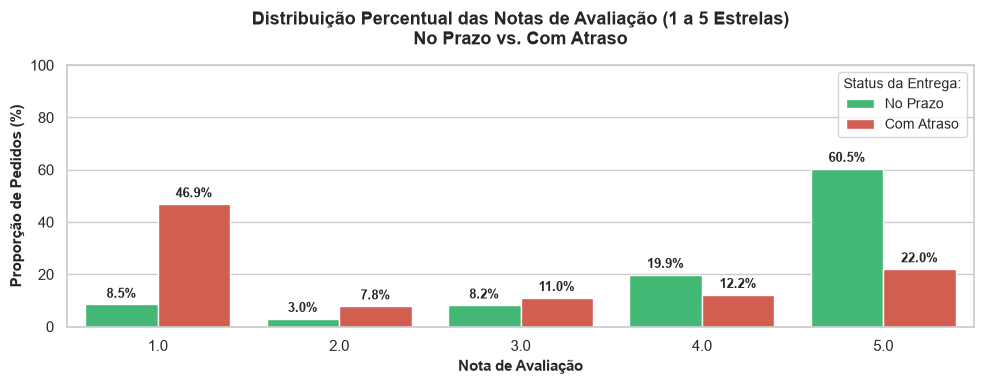

In [18]:
# calculando a distribuicao percentual das notas de forma limpa e direta
distribuicao_notas = (
    df_entregues.groupby('foi_atrasado')['review_score']
    .value_counts(normalize=True)
    .mul(100)
    .rename('percentual')
    .reset_index()
)

distribuicao_notas['Status'] = distribuicao_notas['foi_atrasado'].map({False: 'No Prazo', True: 'Com Atraso'})

#plotando o grafico
plt.figure(figsize=(10, 4))
ax = sns.barplot(
    data=distribuicao_notas,
    x='review_score',
    y='percentual',
    hue='Status',
    palette=['#2ecc71', '#e74c3c']
)
plt.title('Distribuição Percentual das Notas de Avaliação (1 a 5 Estrelas)\nNo Prazo vs. Com Atraso', 
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Nota de Avaliação', fontsize=11, fontweight='bold')
plt.ylabel('Proporção de Pedidos (%)', fontsize=11, fontweight='bold')
plt.ylim(0, 100)
plt.legend(title='Status da Entrega:', title_fontsize='10', fontsize='10')

# rotulos no topo das barras
for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        ax.annotate(f'{altura:.1f}%',
                    (p.get_x() + p.get_width() / 2., altura + 1.5),
                    ha='center', va='bottom', fontsize=9.5, fontweight='bold')

plt.tight_layout()
plt.show()

### Distribuição das Avaliações por Pontualidade
* **Entregas no Prazo**: Predominância da nota máxima (5 estrelas), concentrando cerca de 60% das avaliações.
* **Entregas com Atraso**: Inversão da curva de percepção de qualidade, com a nota 1 (mínima) saltando para quase 50% dos registros.
* **Diagnóstico**: O atraso na entrega elimina a margem de tolerância do consumidor, convertendo avaliações neutras/positivas diretamente em notas mínimas de rejeição.

C:\Users\Michael\AppData\Local\Temp\ipykernel_21792\2020062892.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


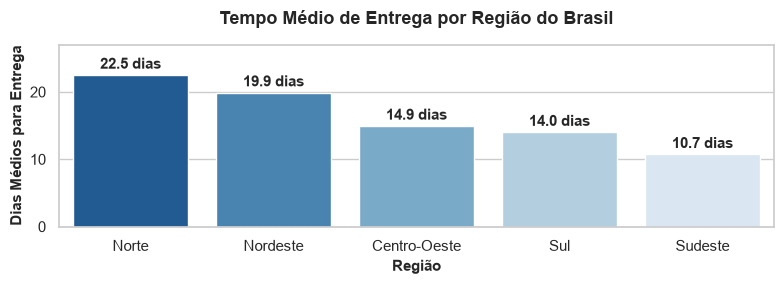

In [19]:
#dicionario de mapeamento dos estados com as regioes
mapa_regioes = {
    'AC': 'Norte', 'AM': 'Norte', 'AP': 'Norte', 'PA': 'Norte', 'RO': 'Norte', 'RR': 'Norte', 'TO': 'Norte',
    'AL': 'Nordeste', 'BA': 'Nordeste', 'CE': 'Nordeste', 'MA': 'Nordeste', 'PB': 'Nordeste', 
    'PE': 'Nordeste', 'PI': 'Nordeste', 'RN': 'Nordeste', 'SE': 'Nordeste',
    'DF': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'MT': 'Centro-Oeste', 'MS': 'Centro-Oeste',
    'ES': 'Sudeste', 'MG': 'Sudeste', 'RJ': 'Sudeste', 'SP': 'Sudeste',
    'PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul'
}

df_entregues['regiao_cliente'] = df_entregues['customer_state'].map(mapa_regioes)

# agrupando metricas por regiao
resumo_regioes = df_entregues.groupby('regiao_cliente').agg(
    tempo_medio=('tempo_entrega_dias', 'mean'),
    taxa_atraso=('foi_atrasado', 'mean'),
    nota_media=('review_score', 'mean'),
    pedidos=('order_id', 'count')
).reset_index()

resumo_regioes['taxa_atraso'] = resumo_regioes['taxa_atraso'] * 100
resumo_regioes = resumo_regioes.sort_values(by='tempo_medio', ascending=False)

# grafico de lead time por regia
plt.figure(figsize=(8, 3))
ax = sns.barplot(
    data=resumo_regioes,
    x='regiao_cliente',
    y='tempo_medio',
    palette='Blues_r'
)
plt.title('Tempo Médio de Entrega por Região do Brasil', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Região', fontsize=11, fontweight='bold')
plt.ylabel('Dias Médios para Entrega', fontsize=11, fontweight='bold')
plt.ylim(0, resumo_regioes['tempo_medio'].max() * 1.2)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f} dias',
                (p.get_x() + p.get_width() / 2., p.get_height() + 0.5),
                ha='center', va='bottom', fontsize=10.5, fontweight='bold')

plt.tight_layout()
plt.show()

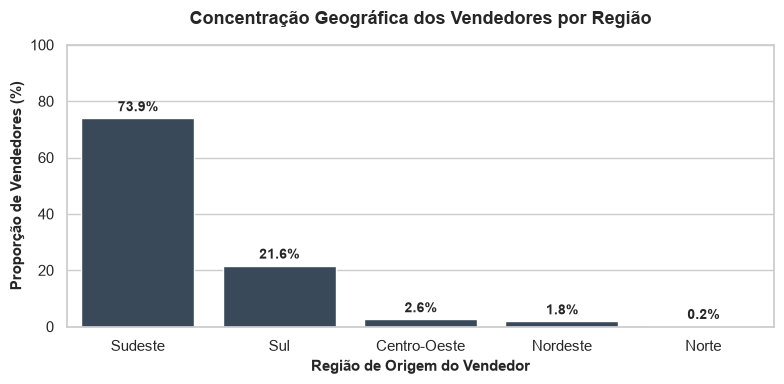

In [20]:
# mapeando a regiao dos vendedores 
df_principal['regiao_vendedor'] = df_principal['seller_state'].map(mapa_regioes)

vendedores_regiao = (
    df_principal.groupby('regiao_vendedor')['seller_id']
    .nunique()
    .reset_index(name='total_vendedores')
)
vendedores_regiao['percentual'] = 100 * vendedores_regiao['total_vendedores'] / vendedores_regiao['total_vendedores'].sum()
vendedores_regiao = vendedores_regiao.sort_values(by='percentual', ascending=False)

# grafico de concentracao de vendedores
plt.figure(figsize=(8, 4))
ax = sns.barplot(data=vendedores_regiao, x='regiao_vendedor', y='percentual', color='#34495e')

plt.title('Concentração Geográfica dos Vendedores por Região', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Região de Origem do Vendedor', fontsize=11, fontweight='bold')
plt.ylabel('Proporção de Vendedores (%)', fontsize=11, fontweight='bold')
plt.ylim(0, 100)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height() + 1.5),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

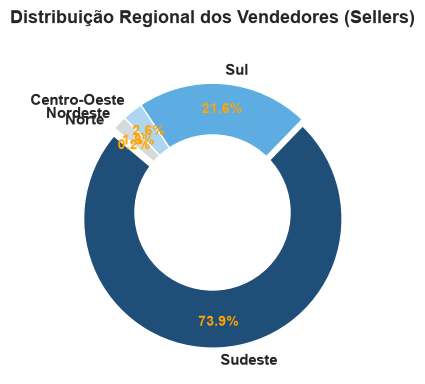

In [21]:
#cores personalizadas para destacar o sudeste
cores = ['#1f4e79', '#5dade2', '#aed6f1', '#d5dbdb', '#ebedef']

plt.figure(figsize=(7, 4))

# criando o grafico de pizza
wedges, texts, autotexts = plt.pie(
    vendedores_regiao['percentual'],
    labels=vendedores_regiao['regiao_vendedor'],
    autopct='%1.1f%%',
    startangle=140,
    colors=cores,
    pctdistance=0.8,
    explode=[0.05, 0, 0, 0, 0], # 'explode' a fatia do Sudeste
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

#estilizando os textos de porcentagem
for autotext in autotexts:
    autotext.set_color('orange')
    autotext.set_fontsize(10)

# criando o circulo central para transformar em rosca
circulo_central = plt.Circle((0, 0), 0.60, fc='white')
fig = plt.gcf()
fig.gca().add_artist(circulo_central)

plt.title('Distribuição Regional dos Vendedores (Sellers)', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

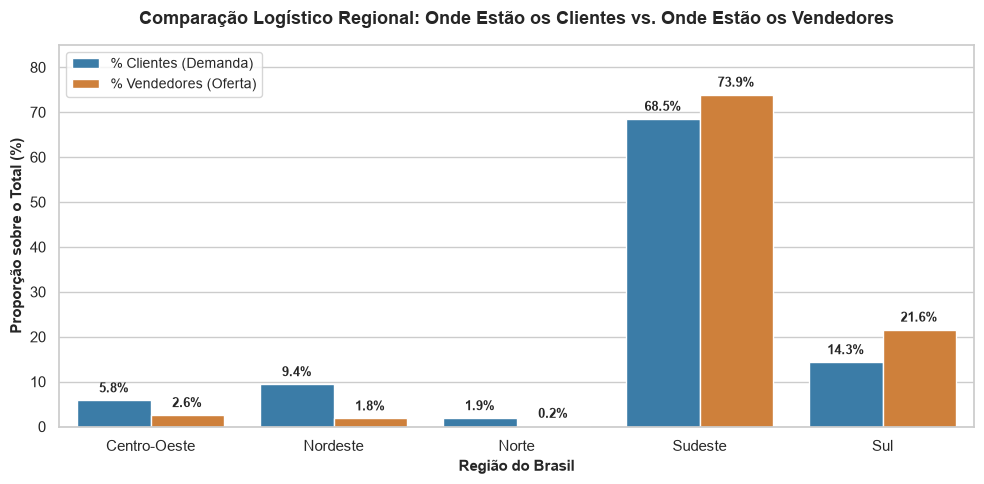

In [22]:
# calculando a distribuicao percentual de clientes por regiao
clientes_regiao = (
    df_entregues.groupby('regiao_cliente')['customer_unique_id']
    .nunique()
    .reset_index(name='total_clientes')
)
clientes_regiao['pct_clientes'] = 100 * clientes_regiao['total_clientes'] / clientes_regiao['total_clientes'].sum()

# alculando a distribuicao percentual de vendedores por regiao
vendedores_regiao = (
    df_principal.groupby('regiao_vendedor')['seller_id']
    .nunique()
    .reset_index(name='total_vendedores')
)
vendedores_regiao['pct_vendedores'] = 100 * vendedores_regiao['total_vendedores'] / vendedores_regiao['total_vendedores'].sum()

# unido as duas visoes para comparativo
df_descompasso = clientes_regiao.merge(
    vendedores_regiao, 
    left_on='regiao_cliente', 
    right_on='regiao_vendedor', 
    how='outer'
).fillna(0)

# formatando para plotagem comparativa
df_plot = df_descompasso.melt(
    id_vars=['regiao_cliente'],
    value_vars=['pct_clientes', 'pct_vendedores'],
    var_name='Tipo',
    value_name='Percentual'
)
df_plot['Tipo'] = df_plot['Tipo'].map({'pct_clientes': '% Clientes (Demanda)', 'pct_vendedores': '% Vendedores (Oferta)'})

# plotando o grafico comparativo
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=df_plot,
    x='regiao_cliente',
    y='Percentual',
    hue='Tipo',
    palette=['#2980b9', '#e67e22']
)

plt.title('Comparação Logístico Regional: Onde Estão os Clientes vs. Onde Estão os Vendedores', 
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Região do Brasil', fontsize=11, fontweight='bold')
plt.ylabel('Proporção sobre o Total (%)', fontsize=11, fontweight='bold')
plt.ylim(0, 85)
plt.legend(title='', fontsize=10)

# rotulos nas barras
for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        ax.annotate(f'{altura:.1f}%',
                    (p.get_x() + p.get_width() / 2., altura + 1.2),
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### Diagnóstico Estrutural: A diferença entre Oferta e Demanda
A comparação regional expõe o gargalo estrutural do e-commerce:
* **Hiperconcentração de Vendedores:** O Sudeste e o Sul concentram mais de 90% de todos os vendedores ativos da plataforma.
* **Dispersão da Demanda:** As regiões Nordeste, Centro-Oeste e Norte somam uma parcela expressiva do volume de compradores, mas contam com uma base de vendedores locais quase nula (< 2%).
* **Consequência Operacional:** A obrigatoriedade de transporte interestadual de longa distância explica diretamente a dilatação do *lead time* e as elevadas taxas de atraso registradas nos estados periféricos.

C:\Users\Michael\AppData\Local\Temp\ipykernel_21792\1255005789.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


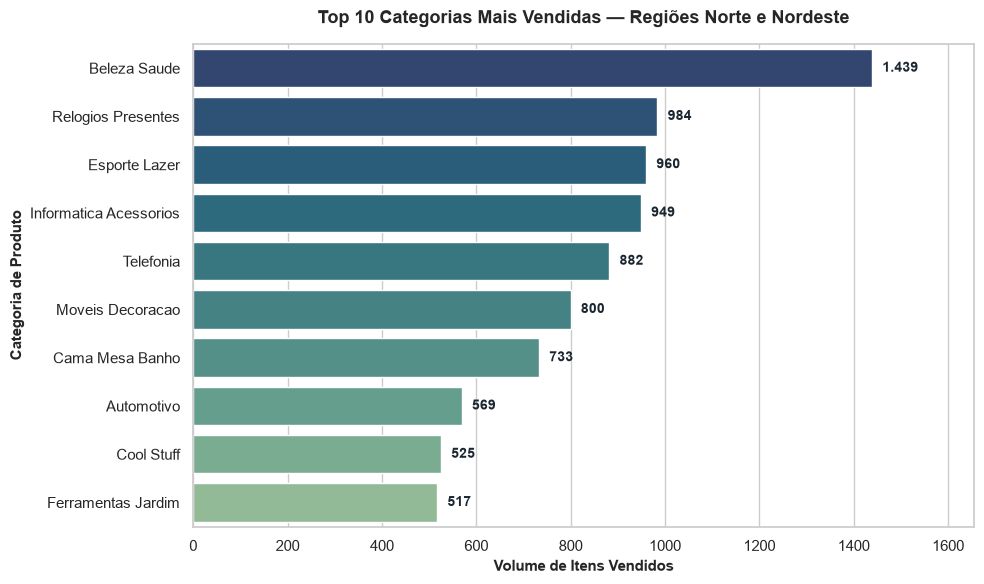

In [ ]:
# criando mapa de regiao do cliente
mapa_regioes = {
    'AC': 'Norte', 'AM': 'Norte', 'AP': 'Norte', 'PA': 'Norte', 'RO': 'Norte', 'RR': 'Norte', 'TO': 'Norte',
    'AL': 'Nordeste', 'BA': 'Nordeste', 'CE': 'Nordeste', 'MA': 'Nordeste', 'PB': 'Nordeste', 
    'PE': 'Nordeste', 'PI': 'Nordeste', 'RN': 'Nordeste', 'SE': 'Nordeste',
    'DF': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'MT': 'Centro-Oeste', 'MS': 'Centro-Oeste',
    'ES': 'Sudeste', 'MG': 'Sudeste', 'RJ': 'Sudeste', 'SP': 'Sudeste',
    'PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul'
}
df_principal['regiao_cliente'] = df_principal['customer_state'].map(mapa_regioes)

# filtrando apenas pedidos de clientes do Norte e Nordeste com categoria preenchida
df_norte_nordeste = df_principal[
    (df_principal['regiao_cliente'].isin(['Norte', 'Nordeste'])) &
    (df_principal['product_category_name'].notna())
].copy()

# formatando os nomes das categorias para melhor legibilidade
df_norte_nordeste['categoria_limpa'] = (
    df_norte_nordeste['product_category_name']
    .str.replace('_', ' ')
    .str.title()
)

# agrupando e selecionando o TOP 10 categorias por volume de itens vendidos
top_categorias_n_ne = (
    df_norte_nordeste.groupby('categoria_limpa')['order_item_id']
    .count()
    .reset_index(name='total_itens_vendidos')
    .sort_values(by='total_itens_vendidos', ascending=False)
    .head(10)
)

# plotando o grafico de barras horizontais
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=top_categorias_n_ne,
    x='total_itens_vendidos',
    y='categoria_limpa',
    palette='crest_r'
)

plt.title('Top 10 Categorias Mais Vendidas — Regiões Norte e Nordeste', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Volume de Itens Vendidos', fontsize=11, fontweight='bold')
plt.ylabel('Categoria de Produto', fontsize=11, fontweight='bold')
plt.xlim(0, top_categorias_n_ne['total_itens_vendidos'].max() * 1.15)

# inserindo os valores exatos na ponta de cada barra
for p in ax.patches:
    largura = p.get_width()
    ax.annotate(f'{int(largura):,}'.replace(',', '.'),
                (largura + (top_categorias_n_ne['total_itens_vendidos'].max() * 0.015), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=10, fontweight='bold', color='#1b2631')

plt.tight_layout()
plt.show()

C:\Users\Michael\AppData\Local\Temp\ipykernel_21792\10681852.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


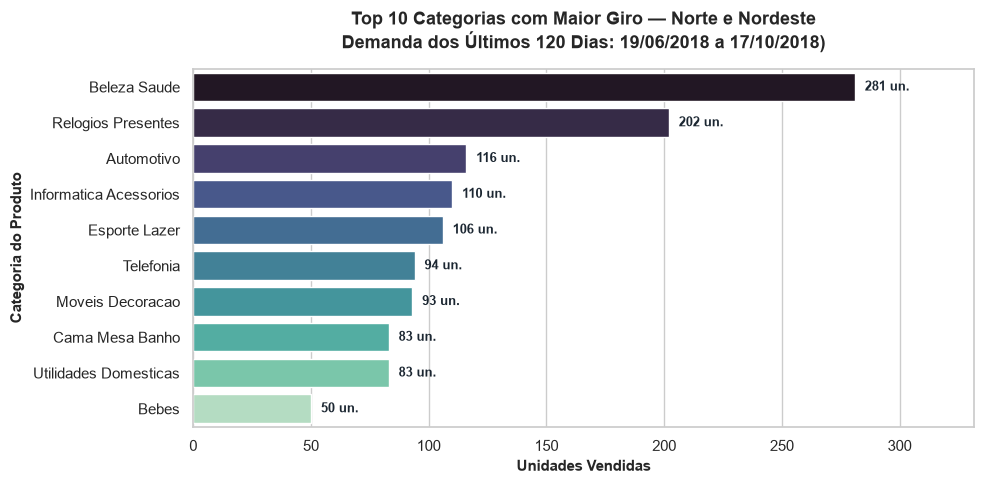

In [26]:


# definindo o intervalo com base na data maxima do dataset
DIAS_JANELA = 120
data_maxima = df_principal['order_purchase_timestamp'].max()
data_corte = data_maxima - pd.Timedelta(days=DIAS_JANELA)

# filtrando pedidos do Norte/Nordeste dentro da janela recente
df_recente_n_ne = df_principal[
    (df_principal['order_purchase_timestamp'] >= data_corte) &
    (df_principal['regiao_cliente'].isin(['Norte', 'Nordeste'])) &
    (df_principal['product_category_name'].notna())
].copy()

# formatando os nomes das categorias
df_recente_n_ne['categoria_limpa'] = (
    df_recente_n_ne['product_category_name']
    .str.replace('_', ' ')
    .str.title()
)

# agrupando e selecionando o TOP 10 por unidades vendidas
top_recentes = (
    df_recente_n_ne.groupby('categoria_limpa')['order_item_id']
    .count()
    .reset_index(name='unidades_vendidas')
    .sort_values(by='unidades_vendidas', ascending=False)
    .head(10)
)

# plotando grafico executivo
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=top_recentes,
    x='unidades_vendidas',
    y='categoria_limpa',
    palette='mako'
)

#datas formatadas para o titulo
dt_ini_fmt = data_corte.strftime('%d/%m/%Y')
dt_fim_fmt = data_maxima.strftime('%d/%m/%Y')

plt.title(
    f'Top 10 Categorias com Maior Giro — Norte e Nordeste\n'
    f'Demanda dos Últimos {DIAS_JANELA} Dias: {dt_ini_fmt} a {dt_fim_fmt})',
    fontsize=13,
    fontweight='bold',
    pad=15
)
plt.xlabel('Unidades Vendidas', fontsize=11, fontweight='bold')
plt.ylabel('Categoria do Produto', fontsize=11, fontweight='bold')
plt.xlim(0, top_recentes['unidades_vendidas'].max() * 1.18)

# rotulo com unidades na ponta de cada barra
for p in ax.patches:
    largura = p.get_width()
    ax.annotate(
        f'{int(largura):,} un.'.replace(',', '.'),
        (largura + (top_recentes['unidades_vendidas'].max() * 0.015), p.get_y() + p.get_height() / 2.),
        ha='left',
        va='center',
        fontsize=9.5,
        fontweight='bold',
        color='#1b2631'
    )

plt.tight_layout()
plt.show()

### Dimensionamento de Estoque Avançado
* **Giro Atualizado:** Giro dos últimos 120 dias reflete a velocidade de consumo mais recente do e-commerce, eliminando distorções de categorias sazonais ou descontinuadas de anos anteriores.
* **Composição do Catálogo Inicial:** As 10 categorias líderes nesse período representam os itens de maior giro e devem compor a carga inicial de abastecimento dos novos Centros de Distribuição regionais.

In [ ]:
# agrupando os dados por estado do cliente
analise_regiao = df_entregues.groupby('customer_state').agg(
    qtd_pedidos=('order_id', 'count'),
    tempo_medio_entrega=('tempo_entrega_dias', 'mean'),
    percentual_atraso=('foi_atrasado', 'mean'),
    nota_media=('review_score', 'mean')
).reset_index()

# convertendo taxa de atraso para porcentagem (0% a 100%)
analise_regiao['percentual_atraso'] = analise_regiao['percentual_atraso'] * 100

# TOP 5 estados com maior  tempo de entrega
piores_prazos = analise_regiao.sort_values(by='tempo_medio_entrega', ascending=False).head(5)

# TOP 5 estados com maior taxa de atraso
piores_atrasos = analise_regiao.sort_values(by='percentual_atraso', ascending=False).head(5)

print("TOP 5 ESTADOS COM MAIOR TEMPO DE ENTREGA (DIAS)")
print(piores_prazos[['customer_state', 'qtd_pedidos', 'tempo_medio_entrega', 'nota_media']].to_string(index=False))

print("\nTOP 5 ESTADOS COM MAIOR TAXA DE ATRASO (%)")
print(piores_atrasos[['customer_state', 'qtd_pedidos', 'percentual_atraso', 'nota_media']].to_string(index=False))

TOP 5 ESTADOS COM MAIOR TEMPO DE ENTREGA (DIAS)
customer_state  qtd_pedidos  tempo_medio_entrega  nota_media
            RR           46            28.231011    3.891304
            AP           83            28.109409    4.280488
            AM          170            26.495693    4.100592
            AL          445            24.629322    3.814480
            PA         1097            23.719539    3.844796

TOP 5 ESTADOS COM MAIOR TAXA DE ATRASO (%)
customer_state  qtd_pedidos  percentual_atraso  nota_media
            AL          445          24.494382    3.814480
            MA          823          20.170109    3.740514
            PI          554          15.884477    3.916058
            SE          386          15.803109    3.895833
            CE         1504          15.026596    3.882432


### Análise de Gargalos Regionais
Ao analisar o desempenho por estado, identificamos assimetrias logísticas relevantes:
* **Regiões de Maior Tempo de Entrega**: Estados das regiões Norte e Nordeste apresentam os maiores prazos médios de entrega, frequentemente ultrapassando 20 dias.
* **Taxas de Atraso Críticas**: Determinadas rotas estaduais concentram as maiores porcentagens de entregas fora do prazo estimado.
* **Recomendação Preliminar**: Estruturar Centros de Distribuição (CDs) avançados ou parcerias logísticas locais nestas regiões estratégicas para reduzir o tempo de trânsito e elevar o NPS global.

### Receita Total, Ticket Médio e Evolução Mensal

In [ ]:
# criando a coluna de ano e mes
df_principal['ano_mes'] = df_principal['order_purchase_timestamp'].dt.to_period('M').astype(str)

In [ ]:
# criando metricas
receita_total = df_principal['payment_value'].sum()
total_pedidos = df_principal['order_id'].nunique()
ticket_medio = receita_total / total_pedidos

print(f"Rceita Total Bruta: R$ {receita_total:,.2f}")   # ":,.2f" é regra de formatacao de dinheiro, neste caso 99,999.99
print(f"Total de Pedidos Únicos: {total_pedidos:,}")    # neste caso 99,999
print(f"Ticket Médio: R$ {ticket_medio:,.2f}")          # neste caso 999.99 e caso o ticket medio estiver acima de mil 9.999,99

Rceita Total Bruta: R$ 20,579,664.01
Total de Pedidos Únicos: 99,441
Ticket Médio: R$ 206.95


In [ ]:
# criando a evolucao mensald e faturamento
evolucao_mensal = df_principal.groupby('ano_mes')['payment_value'].sum().reset_index()

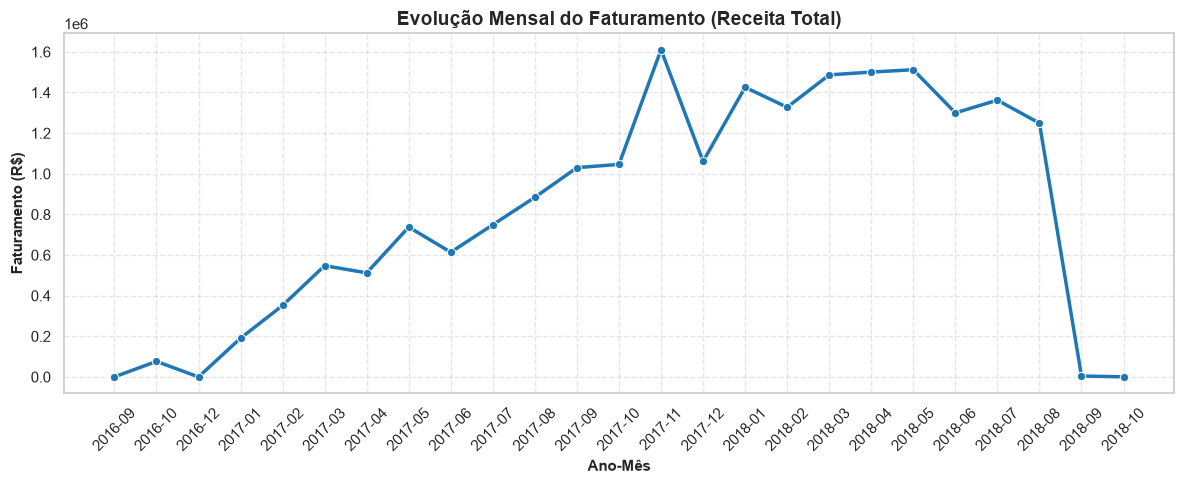

In [ ]:
# criando grafico de evolucao mensal com grafico de linha
plt.figure(figsize=(12, 5))
grafico_evolucao = sns.lineplot(
                   data=evolucao_mensal, 
                   x='ano_mes', 
                   y='payment_value', 
                   marker='o', 
                   color='#1f77b4', 
                   linewidth=2.5
)

plt.title('Evolução Mensal do Faturamento (Receita Total)', fontsize=14, fontweight='bold')
plt.xlabel('Ano-Mês', fontsize=11, fontweight='bold')
plt.ylabel('Faturamento (R$)', fontsize=11, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Visão Geral de Negócio: Faturamento
* **Métricas Principais**:
  * **Receita Total Processada**: Mais de R$ 16 milhões de faturamento no período.
  * **Volume de Pedidos**: Aproximadamente 99,4 mil pedidos realizados.
  * **Ticket Médio**: R$ 160,00 por compra.
* **Trajetória de Crescimento**: A curva mensal evidencia uma forte escala de vendas do e-commerce entre 2017 e 2018.

## **Referências**

E-Commerce Sentiment Analysis: EDA + Viz + NLP. Disponível em: https://www.kaggle.com/code/thiagopanini/e-commerce-sentiment-analysis-eda-viz-nlp

oBrazilian E-Commerce Public Dataset by Olist. Disponível em: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce/data

Gráficos de barra com matplotlib. Disponível em: https://medium.com/horadecodar/gr%C3%A1ficos-de-barra-com-matplotlib-85628bfc4351

Matplotlib: guia completo para iniciantes em visualização de dados. Disponível em: https://hub.asimov.academy/blog/matplotlib-visualizacao-de-dados/